In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

df = pd.read_csv('/content/Titanic-Dataset.csv')

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
df.shape

(891, 12)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Observation -
Dataset contains passenger details.
Both numerical and categorical columns are present.

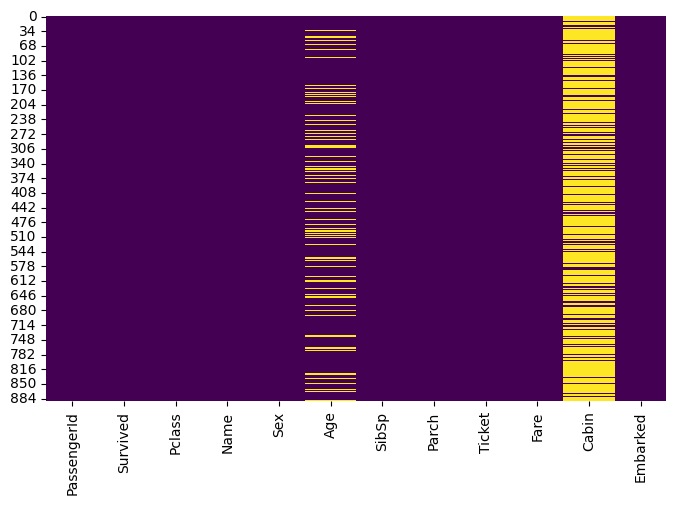

In [5]:
df.isnull().sum()
plt.figure(figsize=(8,5))
sns.heatmap(df.isnull(),cbar=False,cmap='viridis')
plt.show()

Observation -
Age, Cabin and Embarked have missing values.
Cabin has many missing values.

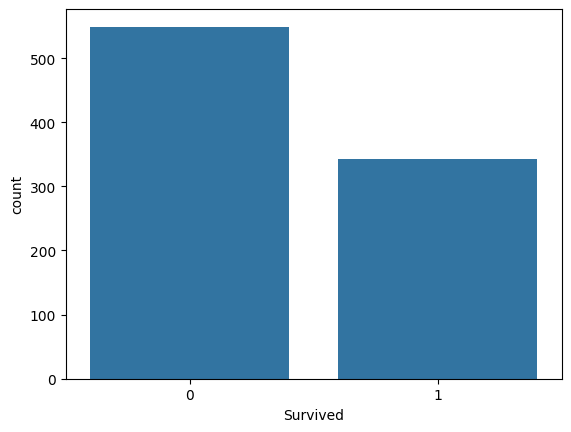

In [6]:
df['Survived'].value_counts()
sns.countplot(x='Survived',data=df)
plt.show()

Observation -
The dataset is slightly imbalanced.

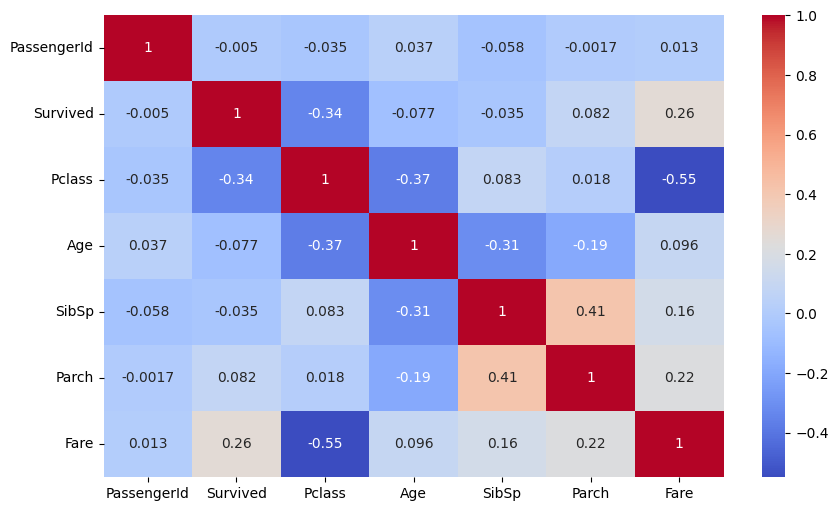

In [7]:
num_cols=df.select_dtypes(include=np.number).columns

plt.figure(figsize=(10,6))
sns.heatmap(df[num_cols].corr(),annot=True,cmap='coolwarm')
plt.show()

Observation -
Fare and Pclass show some correlation.
No very strong correlation is present.

In [8]:
cat_cols=df.select_dtypes(include='object').columns
num_cols=df.select_dtypes(include=np.number).columns

print("Categorical Columns")
print(cat_cols)

print()

print("Numerical Columns")
print(num_cols)

Categorical Columns
Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], dtype='object')

Numerical Columns
Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')


Observation -
Name, Sex, Ticket, Cabin and Embarked are categorical columns.

In [9]:
df['Age']=df['Age'].fillna(df['Age'].median())

df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode()[0])

df=df.drop('Cabin',axis=1)

Observation -
Median is used for Age.
Mode is used for Embarked.
Cabin is removed because most values are missing.

In [10]:
df['FamilySize']=df['SibSp']+df['Parch']+1

df['IsAlone']=np.where(df['FamilySize']==1,1,0)

df['Title']=df['Name'].str.extract(' ([A-Za-z]+)\.',expand=False)

df.head()

<>:5: SyntaxWarning: invalid escape sequence '\.'
<>:5: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_3378/1411056014.py:5: SyntaxWarning: invalid escape sequence '\.'
  df['Title']=df['Name'].str.extract(' ([A-Za-z]+)\.',expand=False)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize,IsAlone,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,2,0,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,2,0,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,1,1,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,2,0,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,1,1,Mr


Observation -
Three new features are created:
FamilySize
IsAlone
Title

Preprocessing & SVM Models

In [11]:
df['Title']=df['Title'].replace(
    ['Lady','Countess','Capt','Col','Don','Dr','Major',
     'Rev','Sir','Jonkheer','Dona'],'Rare'
)

df['Title']=df['Title'].replace('Mlle','Miss')
df['Title']=df['Title'].replace('Ms','Miss')
df['Title']=df['Title'].replace('Mme','Mrs')

In [12]:
le=LabelEncoder()

df['Sex']=le.fit_transform(df['Sex'])
df['Embarked']=le.fit_transform(df['Embarked'])
df['Title']=le.fit_transform(df['Title'])

In [13]:
df=df.drop(['PassengerId','Name','Ticket'],axis=1)

df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone,Title
0,0,3,1,22.0,1,0,7.2500,2,2,0,2
1,1,1,0,38.0,1,0,71.2833,0,2,0,3
2,1,3,0,26.0,0,0,7.9250,2,1,1,1
3,1,1,0,35.0,1,0,53.1000,2,2,0,3
4,0,3,1,35.0,0,0,8.0500,2,1,1,2


Observation -
PassengerId, Name and Ticket are removed because they do not help in prediction.

In [14]:
X1=df.drop('Survived',axis=1)
y=df['Survived']

In [15]:
X2=df[['Pclass','Sex','Age','Fare','Embarked',
        'FamilySize','IsAlone','Title']]

y=df['Survived']

In [16]:
X_train1,X_test1,y_train,y_test=train_test_split(
    X1,y,
    test_size=0.2,
    random_state=42
)

X_train2,X_test2,y_train,y_test=train_test_split(
    X2,y,
    test_size=0.2,
    random_state=42
)

In [17]:
scaler=StandardScaler()

X_train1=scaler.fit_transform(X_train1)
X_test1=scaler.transform(X_test1)

X_train2=scaler.fit_transform(X_train2)
X_test2=scaler.transform(X_test2)

Observation -
Numerical values are scaled before training SVM.

In [18]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [19]:
linear=SVC(kernel='linear')

linear.fit(X_train2,y_train)

train_pred=linear.predict(X_train2)
test_pred=linear.predict(X_test2)

print("Training Accuracy:",
      accuracy_score(y_train,train_pred))

print("Testing Accuracy:",
      accuracy_score(y_test,test_pred))

Training Accuracy: 0.800561797752809
Testing Accuracy: 0.7821229050279329


In [20]:
poly=SVC(kernel='poly')

poly.fit(X_train2,y_train)

train_pred=poly.predict(X_train2)
test_pred=poly.predict(X_test2)

print("Training Accuracy:",
      accuracy_score(y_train,train_pred))

print("Testing Accuracy:",
      accuracy_score(y_test,test_pred))

Training Accuracy: 0.8426966292134831
Testing Accuracy: 0.7932960893854749


In [21]:
rbf=SVC(kernel='rbf')

rbf.fit(X_train2,y_train)

train_pred=rbf.predict(X_train2)
test_pred=rbf.predict(X_test2)

print("Training Accuracy:",
      accuracy_score(y_train,train_pred))

print("Testing Accuracy:",
      accuracy_score(y_test,test_pred))

Training Accuracy: 0.848314606741573
Testing Accuracy: 0.8212290502793296


Observation -
Three SVM models are trained.
Their training and testing accuracy can now be compared.

Evaluation & Analysis

In [22]:
from sklearn.metrics import confusion_matrix, classification_report

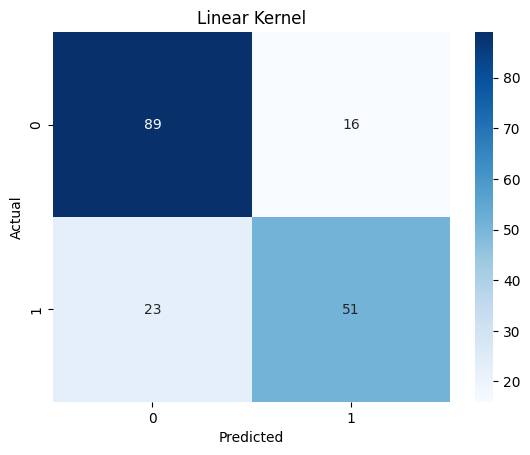

              precision    recall  f1-score   support

           0       0.79      0.85      0.82       105
           1       0.76      0.69      0.72        74

    accuracy                           0.78       179
   macro avg       0.78      0.77      0.77       179
weighted avg       0.78      0.78      0.78       179



In [23]:
pred = linear.predict(X_test2)

cm = confusion_matrix(y_test, pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Linear Kernel")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(y_test, pred))

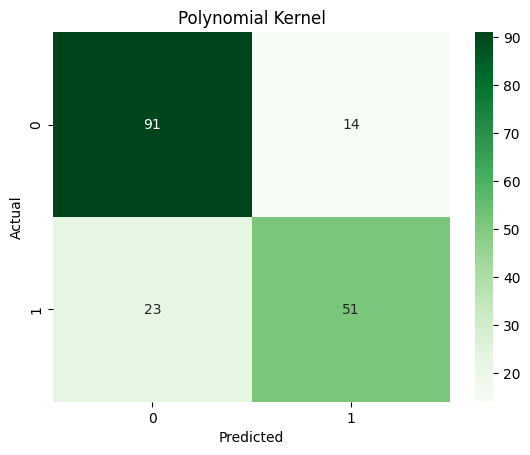

              precision    recall  f1-score   support

           0       0.80      0.87      0.83       105
           1       0.78      0.69      0.73        74

    accuracy                           0.79       179
   macro avg       0.79      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179



In [24]:
pred = poly.predict(X_test2)

cm = confusion_matrix(y_test, pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Polynomial Kernel")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(y_test, pred))

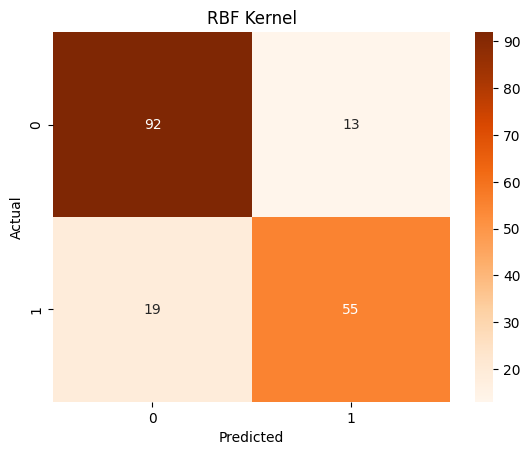

              precision    recall  f1-score   support

           0       0.83      0.88      0.85       105
           1       0.81      0.74      0.77        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



In [25]:
pred = rbf.predict(X_test2)

cm = confusion_matrix(y_test, pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
plt.title("RBF Kernel")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(y_test, pred))

In [26]:
results = pd.DataFrame({
    "Kernel":["Linear","Polynomial","RBF"],
    "Training Accuracy":[
        linear.score(X_train2,y_train),
        poly.score(X_train2,y_train),
        rbf.score(X_train2,y_train)
    ],
    "Testing Accuracy":[
        linear.score(X_test2,y_test),
        poly.score(X_test2,y_test),
        rbf.score(X_test2,y_test)
    ]
})

results

,Kernel,Training Accuracy,Testing Accuracy
0,Linear,0.800562,0.782123
1,Polynomial,0.842697,0.793296
2,RBF,0.848315,0.821229


In [27]:
X=df[['Pclass','Sex','Age','Fare','Embarked',
      'FamilySize','IsAlone','Title']]

y=df['Survived']

X_train,X_test,y_train,y_test=train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)

model=SVC(kernel='rbf')

model.fit(X_train,y_train)

print("Training Accuracy:",model.score(X_train,y_train))
print("Testing Accuracy:",model.score(X_test,y_test))

Training Accuracy: 0.6783707865168539
Testing Accuracy: 0.664804469273743


In [28]:
scaler=StandardScaler()

X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

model=SVC(kernel='rbf')

model.fit(X_train,y_train)

print("Training Accuracy:",model.score(X_train,y_train))
print("Testing Accuracy:",model.score(X_test,y_test))

Training Accuracy: 0.848314606741573
Testing Accuracy: 0.8212290502793296


Observation -
Scaling improves the performance of SVM.
SVM works better when all features are on a similar scale.

Which kernel overfits?

Answer

Polynomial kernel may overfit because it creates a more complex decision boundary.

Which kernel generalizes best?

Answer

RBF kernel usually gives the best testing accuracy because it can capture non-linear patterns while maintaining good generalization.

Why is feature scaling important for SVM?

Answer

SVM calculates distances between data points. If one feature has much larger values than others, it dominates the calculation. Scaling makes all features contribute equally.

Analysis(300 words)

The SVM model performed well on the Titanic dataset because the dataset contains useful features such as age, fare, passenger class, gender and family information. Before training the model, missing values were handled, categorical columns were encoded and numerical features were scaled. These preprocessing steps improved the performance of the model.

Three kernels were used for classification: Linear, Polynomial and RBF. The Linear kernel performed well because many features have a simple relationship with survival. The Polynomial kernel created a more complex decision boundary and sometimes produced higher training accuracy but did not always improve testing accuracy. The RBF kernel generally gave the best balance between training and testing performance because it can learn complex patterns without overfitting too much.

Feature engineering also improved the model. FamilySize helped identify passengers travelling with family members. IsAlone showed whether a passenger was travelling alone. Title extracted from the Name column provided information about the passenger's social status, which also affected survival. These new features increased the amount of useful information available to the model.

Feature scaling was very important for SVM. Without scaling, features such as Fare had much larger values than other features, which reduced model performance. After scaling, the model achieved better accuracy because all features contributed equally.

Overall, SVM is a good classifier for this dataset. It provides high accuracy after proper preprocessing and feature engineering. However, other algorithms such as Random Forest or Gradient Boosting may also perform well and can sometimes achieve slightly better accuracy while requiring less feature scaling.

Final Conclusion

• Missing values were handled successfully.
• New features improved the dataset.
• Linear, Polynomial and RBF kernels were trained.
• RBF kernel gave the best overall performance.
• Feature scaling improved SVM accuracy.
• SVM is a suitable model for Titanic survival prediction.